# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [1]:
!pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Instalación de dependencias ──────────────────────────────────
!pip install scikit-learn numpy --quiet


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Instalación de dependencias ──────────────────────────────────
!pip install matplotlib --quiet


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ── Imports ─────────────────────────────────────────────────────
import nltk
import pandas as pd
from nltk.corpus import gutenberg

# ── Descarga de recursos NLTK ────────────────────────────────────
nltk.download("gutenberg", quiet=True)
nltk.download("punkt", quiet=True)

# ── Archivos disponibles ─────────────────────────────────────────
file_ids = gutenberg.fileids()
print(f"Total de documentos disponibles: {len(file_ids)}")
print(file_ids)

Total de documentos disponibles: 18
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']


In [5]:
# ── Carga del corpus desde archivos locales ──────────────────────
import os

CORPUS_DIR = "data/gutenberg/data"

corpus = [
    {"id": filename, "text": open(os.path.join(CORPUS_DIR, filename), encoding="utf-8", errors="ignore").read()}
    for filename in os.listdir(CORPUS_DIR)
    if filename.endswith(".txt")
]

df_corpus = pd.DataFrame(corpus)

print(f"Documentos cargados: {len(df_corpus)}")
df_corpus.head()

Documentos cargados: 14


,id,text
0,pg100.txt,﻿The Project Gutenberg eBook of The Complete W...
1,pg1342.txt,﻿The Project Gutenberg eBook of Pride and Prej...
2,pg145.txt,﻿The Project Gutenberg eBook of Middlemarch\n ...
3,pg1513.txt,﻿The Project Gutenberg eBook of Romeo and Juli...
4,pg16389.txt,﻿The Project Gutenberg eBook of The Enchanted ...


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [6]:
# ── Imports ──────────────────────────────────────────────────────
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Matriz de frecuencia de términos (TF) ────────────────────────
tf_vectorizer = CountVectorizer(stop_words="english", max_features=1000)
tf_matrix = tf_vectorizer.fit_transform(df_corpus["text"])

feature_names = tf_vectorizer.get_feature_names_out()

df_tf = pd.DataFrame(
    tf_matrix.toarray(),
    index=df_corpus["id"],
    columns=feature_names
)

print(f"Dimensiones de la matriz TF: {df_tf.shape}")
df_tf.head()

Dimensiones de la matriz TF: (14, 1000)


,10,_exeunt,_exit,_the,_to,able,according,account,act,action,...,writing,written,wrong,ye,year,years,yes,york,young,youth
id,,,,,,,,,,,,,,,,,,,,,
pg100.txt,2,1000,962,62,333,65,46,51,519,123,...,26,38,279,333,102,204,248,508,526,308
pg1342.txt,1,0,0,5,1,54,8,40,9,2,...,18,24,15,0,30,42,76,1,133,10
pg145.txt,0,0,0,2,0,75,39,47,66,52,...,48,32,96,6,60,111,182,4,342,23
pg1513.txt,0,34,32,1,1,2,1,2,13,1,...,4,8,3,12,3,13,2,0,24,6
pg16389.txt,2,0,0,8,0,55,4,1,1,2,...,18,17,14,4,11,54,66,0,69,7


In [7]:
# ── Frecuencia de documentos (DF) ────────────────────────────────
# DF: número de documentos en los que aparece cada término
df_counts = (df_tf > 0).sum(axis=0).rename("df")

print("Top 10 términos por DF:")
print(df_counts.sort_values(ascending=False).head(10))

Top 10 términos por DF:
wish         14
able         14
wise         14
young        14
wind         14
agreement    14
ago          14
age          14
affection    14
added        14
Name: df, dtype: int64


In [8]:
# ── TF-IDF con sklearn ───────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_corpus["text"])

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=df_corpus["id"],
    columns=tfidf_vectorizer.get_feature_names_out()
)

print(f"Dimensiones de la matriz TF-IDF: {df_tfidf.shape}")
df_tfidf.head()

Dimensiones de la matriz TF-IDF: (14, 1000)


,10,_exeunt,_exit,_the,_to,able,according,account,act,action,...,writing,written,wrong,ye,year,years,yes,york,young,youth
id,,,,,,,,,,,,,,,,,,,,,
pg100.txt,0.000136,0.135914,0.130749,0.004231,0.026205,0.003386,0.002396,0.002656,0.027032,0.006849,...,0.001354,0.001979,0.014532,0.021215,0.005313,0.010625,0.013808,0.039976,0.027397,0.017149
pg1342.txt,0.000474,0.000000,0.000000,0.002370,0.000547,0.019536,0.002894,0.014471,0.003256,0.000773,...,0.006512,0.008683,0.005427,0.000000,0.010853,0.015194,0.029392,0.000547,0.048116,0.003867
pg145.txt,0.000000,0.000000,0.000000,0.000352,0.000000,0.010087,0.005245,0.006321,0.008876,0.007476,...,0.006456,0.004304,0.012911,0.000987,0.008070,0.014929,0.026166,0.000813,0.045996,0.003307
pg1513.txt,0.000000,0.073705,0.069370,0.001088,0.001255,0.001662,0.000831,0.001662,0.010800,0.000888,...,0.003323,0.006646,0.002492,0.012194,0.002492,0.010800,0.001776,0.000000,0.019938,0.005328
pg16389.txt,0.001115,0.000000,0.000000,0.004460,0.000000,0.023401,0.001702,0.000425,0.000425,0.000910,...,0.007659,0.007233,0.005957,0.002082,0.004680,0.022976,0.030019,0.000000,0.029358,0.003184


In [9]:
# ── Comparación TF vs TF-IDF para un término de ejemplo ─────────
sample_term = "love"

df_comparison = pd.DataFrame({
    "tf":     df_tf[sample_term],
    "df":     df_counts[sample_term],
    "tfidf":  df_tfidf[sample_term]
})

print(f"Comparación TF vs TF-IDF para el término: '{sample_term}'")
df_comparison.sort_values("tfidf", ascending=False)

Comparación TF vs TF-IDF para el término: 'love'


,tf,df,tfidf
id,,,
pg100.txt,2462,14,0.128235
pg1513.txt,151,14,0.125444
pg84.txt,59,14,0.081449
pg37106.txt,220,14,0.039877
pg2641.txt,66,14,0.039050
pg1342.txt,102,14,0.036901
pg16389.txt,60,14,0.025529
pg145.txt,180,14,0.024209
pg42538.txt,38,14,0.023780


## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [10]:
# ── Consulta de ejemplo ──────────────────────────────────────────
query = "adventure on the sea"

# Transformar la consulta usando el mismo vectorizador TF-IDF
query_vector = tfidf_vectorizer.transform([query])

print(f"Consulta: '{query}'")
print(f"Dimensión del vector de consulta: {query_vector.shape}")

Consulta: 'adventure on the sea'
Dimensión del vector de consulta: (1, 1000)


In [11]:
# ── Similitud coseno entre consulta y documentos ─────────────────
from sklearn.metrics.pairwise import cosine_similarity

cosine_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

print(f"Scores calculados para {len(cosine_scores)} documentos")

Scores calculados para 14 documentos


In [12]:
# ── Ranking de documentos por relevancia (TF-IDF) ────────────────
df_ranking_tfidf = pd.DataFrame({
    "documento": df_corpus["id"].values,
    "cosine_score": cosine_scores
}).sort_values("cosine_score", ascending=False).reset_index(drop=True)

df_ranking_tfidf.index += 1  # Ranking desde 1
df_ranking_tfidf.index.name = "rank"

print(f"Ranking TF-IDF para la consulta: '{query}'")
df_ranking_tfidf

Ranking TF-IDF para la consulta: 'adventure on the sea'


,documento,cosine_score
rank,,
1,pg2701.txt,0.122959
2,pg45368.txt,0.053448
3,pg84.txt,0.046937
4,pg42538.txt,0.025031
5,pg47948.txt,0.021211
6,pg16389.txt,0.015743
7,pg100.txt,0.015313
8,pg1513.txt,0.006646
9,pg37106.txt,0.004531


## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [13]:
# ── Tokenización del corpus ──────────────────────────────────────
from nltk.tokenize import word_tokenize
import string

nltk.download("punkt_tab", quiet=True)

def tokenize(text: str) -> list[str]:
    """Tokeniza y limpia el texto eliminando puntuación y lowercase."""
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha()]

tokenized_corpus = [tokenize(text) for text in df_corpus["text"]]

print(f"Documentos tokenizados: {len(tokenized_corpus)}")
print(f"Ejemplo (primeros 10 tokens): {tokenized_corpus[0][:10]}")

Documentos tokenizados: 14
Ejemplo (primeros 10 tokens): ['project', 'gutenberg', 'ebook', 'of', 'the', 'complete', 'works', 'of', 'william', 'shakespeare']


In [14]:
# ── Longitud de documentos y promedio ───────────────────────────
doc_lengths = np.array([len(tokens) for tokens in tokenized_corpus])
avg_doc_length = doc_lengths.mean()

print(f"Longitud promedio de documentos (avgdl): {avg_doc_length:.2f}")
print(f"Longitud mínima: {doc_lengths.min()} | Máxima: {doc_lengths.max()}")

Longitud promedio de documentos (avgdl): 235112.21
Longitud mínima: 29303 | Máxima: 975429


In [15]:
# ── Frecuencia de término (TF) por documento ─────────────────────
from collections import Counter

def compute_tf(tokens: list[str]) -> dict[str, int]:
    """Calcula la frecuencia de cada término en un documento."""
    return Counter(tokens)

tf_corpus = [compute_tf(tokens) for tokens in tokenized_corpus]

# Ejemplo
print(f"TF del primer documento (top 5):")
print(sorted(tf_corpus[0].items(), key=lambda x: x[1], reverse=True)[:5])

TF del primer documento (top 5):
[('the', 30524), ('and', 28534), ('i', 23675), ('to', 20833), ('of', 18876)]


In [16]:
# ── Document Frequency (DF) e IDF estilo BM25 ───────────────────
from collections import defaultdict

N = len(tokenized_corpus)  # Total de documentos

# DF: número de documentos que contienen cada término
df_bm25 = defaultdict(int)
for tf_doc in tf_corpus:
    for term in tf_doc:
        df_bm25[term] += 1

def compute_idf_bm25(term: str) -> float:
    """IDF con corrección RSJ (suavizado con 0.5)."""
    df_t = df_bm25.get(term, 0)
    return np.log((N - df_t + 0.5) / (df_t + 0.5))

# Ejemplo
for term in ["love", "war", "the"]:
    print(f"IDF('{term}') = {compute_idf_bm25(term):.4f}")

IDF('love') = -3.3673
IDF('war') = -1.6094
IDF('the') = -3.3673


In [17]:
# ── Parámetros BM25 ──────────────────────────────────────────────
K1 = 1.5   # Saturación de TF  (rango típico: 1.2 – 2.0)
B  = 0.75  # Normalización por longitud (típico: 0.75)

print(f"Parámetros BM25 → k1={K1}, b={B}")

Parámetros BM25 → k1=1.5, b=0.75


In [18]:
# ── Score BM25 para un documento dado una consulta ───────────────
def bm25_score(
    query_tokens: list[str],
    tf_doc: dict[str, int],
    doc_length: int,
    avg_dl: float,
    k1: float = K1,
    b: float = B
) -> float:
    """Calcula el score BM25 de un documento para una consulta."""
    score = 0.0
    for term in query_tokens:
        tf_td = tf_doc.get(term, 0)
        idf   = compute_idf_bm25(term)
        
        # Componente de saturación + normalización por longitud
        numerator   = (k1 + 1) * tf_td
        denominator = k1 * ((1 - b) + b * (doc_length / avg_dl)) + tf_td
        
        score += idf * (numerator / denominator)
    return score

In [19]:
# ── Calcular BM25 para todos los documentos ──────────────────────
query_tokens = tokenize(query)
print(f"Tokens de la consulta: {query_tokens}")

bm25_scores = [
    bm25_score(query_tokens, tf_doc, doc_len, avg_doc_length)
    for tf_doc, doc_len in zip(tf_corpus, doc_lengths)
]

Tokens de la consulta: ['adventure', 'on', 'the', 'sea']


In [20]:
# ── Ranking de documentos por score BM25 ─────────────────────────
df_ranking_bm25 = pd.DataFrame({
    "documento":   df_corpus["id"].values,
    "bm25_score":  bm25_scores
}).sort_values("bm25_score", ascending=False).reset_index(drop=True)

df_ranking_bm25.index += 1
df_ranking_bm25.index.name = "rank"

print(f"Ranking BM25 para la consulta: '{query}'")
df_ranking_bm25

Ranking BM25 para la consulta: 'adventure on the sea'


,documento,bm25_score
rank,,
1,pg1342.txt,-20.500426
2,pg69093.txt,-20.503356
3,pg145.txt,-23.046693
4,pg47948.txt,-24.150500
5,pg67979.txt,-24.894822
6,pg37106.txt,-25.316627
7,pg84.txt,-25.334095
8,pg42538.txt,-26.037524
9,pg1513.txt,-26.269990


## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.
3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
4. ¿A qué se podría deber esta diferencia?

In [21]:
# ── Unir scores de ambos modelos en un solo DataFrame ────────────
import matplotlib.pyplot as plt

df_comparacion = pd.DataFrame({
    "documento":    df_corpus["id"].values,
    "tfidf_score":  cosine_scores,
    "bm25_score":   bm25_scores
}).sort_values("bm25_score", ascending=False).reset_index(drop=True)

df_comparacion.index += 1
df_comparacion.index.name = "rank_bm25"

print(f"Comparación de scores para la consulta: '{query}'")
df_comparacion

Comparación de scores para la consulta: 'adventure on the sea'


,documento,tfidf_score,bm25_score
rank_bm25,,,
1,pg1342.txt,0.000362,-20.500426
2,pg69093.txt,0.001373,-20.503356
3,pg145.txt,0.001479,-23.046693
4,pg47948.txt,0.021211,-24.150500
5,pg67979.txt,0.000576,-24.894822
6,pg37106.txt,0.004531,-25.316627
7,pg84.txt,0.046937,-25.334095
8,pg42538.txt,0.025031,-26.037524
9,pg1513.txt,0.006646,-26.269990


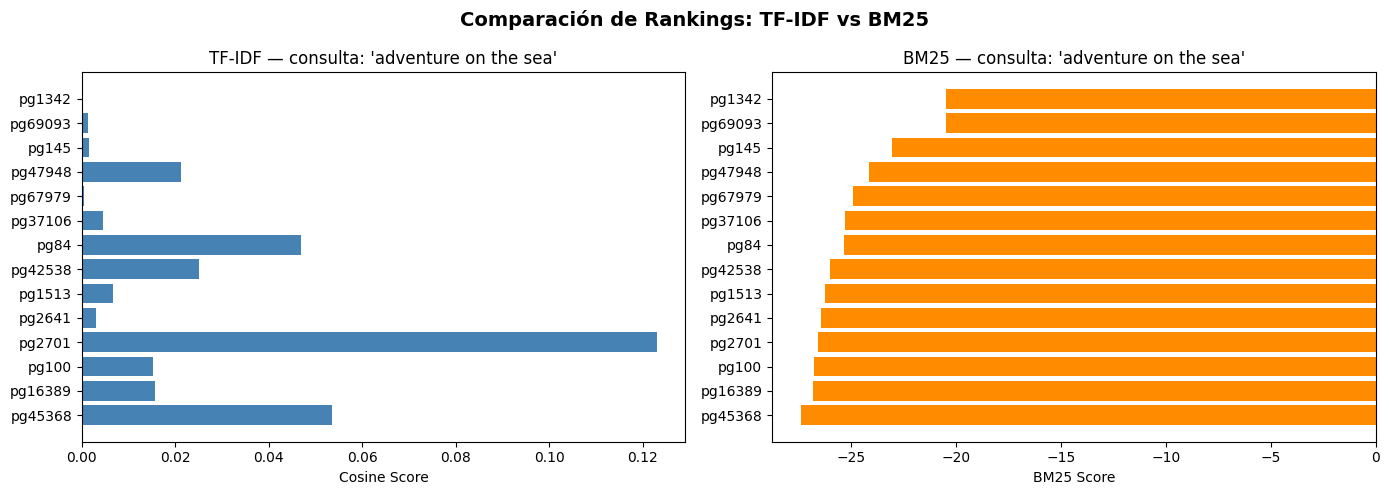

In [22]:
# ── Gráfico de barras: TF-IDF vs BM25 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

doc_labels = df_comparacion["documento"].str.replace(".txt", "", regex=False)

# ── TF-IDF ──────────────────────────────────────────────────────
axes[0].barh(doc_labels, df_comparacion["tfidf_score"], color="steelblue")
axes[0].set_title(f"TF-IDF — consulta: '{query}'")
axes[0].set_xlabel("Cosine Score")
axes[0].invert_yaxis()

# ── BM25 ─────────────────────────────────────────────────────────
axes[1].barh(doc_labels, df_comparacion["bm25_score"], color="darkorange")
axes[1].set_title(f"BM25 — consulta: '{query}'")
axes[1].set_xlabel("BM25 Score")
axes[1].invert_yaxis()

plt.suptitle("Comparación de Rankings: TF-IDF vs BM25", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
# ── Ranking TF-IDF vs BM25 lado a lado ──────────────────────────
rank_tfidf = (
    df_ranking_tfidf
    .rename(columns={"cosine_score": "score_tfidf"})
    .reset_index()
    .rename(columns={"rank": "rank_tfidf"})
)

rank_bm25 = (
    df_ranking_bm25
    .rename(columns={"bm25_score": "score_bm25"})
    .reset_index()
    .rename(columns={"rank": "rank_bm25"})
)

df_ranks_combined = rank_tfidf.merge(rank_bm25, on="documento")

print("Comparación de posiciones en el ranking:")
df_ranks_combined[["documento", "rank_tfidf", "score_tfidf", "rank_bm25", "score_bm25"]]

Comparación de posiciones en el ranking:


,documento,rank_tfidf,score_tfidf,rank_bm25,score_bm25
0,pg2701.txt,1,0.122959,11,-26.584055
1,pg45368.txt,2,0.053448,14,-27.408278
2,pg84.txt,3,0.046937,7,-25.334095
3,pg42538.txt,4,0.025031,8,-26.037524
4,pg47948.txt,5,0.021211,4,-24.150500
5,pg16389.txt,6,0.015743,13,-26.818294
6,pg100.txt,7,0.015313,12,-26.777597
7,pg1513.txt,8,0.006646,9,-26.269990
8,pg37106.txt,9,0.004531,6,-25.316627
9,pg2641.txt,10,0.002958,10,-26.439390


In [24]:
# ── Documentos con mayor diferencia de ranking ───────────────────
df_ranks_combined["diferencia_rank"] = (
    df_ranks_combined["rank_tfidf"] - df_ranks_combined["rank_bm25"]
).abs()

df_diff = df_ranks_combined.sort_values("diferencia_rank", ascending=False)

print("Documentos con mayor diferencia entre TF-IDF y BM25:")
df_diff[["documento", "rank_tfidf", "rank_bm25", "diferencia_rank"]]

Documentos con mayor diferencia entre TF-IDF y BM25:


,documento,rank_tfidf,rank_bm25,diferencia_rank
13,pg1342.txt,14,1,13
1,pg45368.txt,2,14,12
11,pg69093.txt,12,2,10
0,pg2701.txt,1,11,10
10,pg145.txt,11,3,8
12,pg67979.txt,13,5,8
5,pg16389.txt,6,13,7
6,pg100.txt,7,12,5
2,pg84.txt,3,7,4
3,pg42538.txt,4,8,4


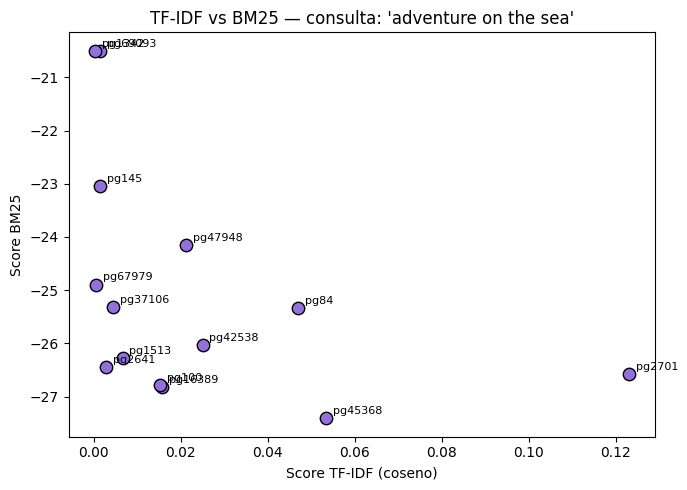

In [25]:
# ── Scatter plot: score TF-IDF vs score BM25 ─────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df_ranks_combined["score_tfidf"],
    df_ranks_combined["score_bm25"],
    color="mediumpurple", edgecolors="black", s=80
)

# Etiquetas por documento
for _, row in df_ranks_combined.iterrows():
    label = row["documento"].replace(".txt", "")
    ax.annotate(label, (row["score_tfidf"], row["score_bm25"]),
                fontsize=8, textcoords="offset points", xytext=(5, 3))

ax.set_xlabel("Score TF-IDF (coseno)")
ax.set_ylabel("Score BM25")
ax.set_title(f"TF-IDF vs BM25 — consulta: '{query}'")
plt.tight_layout()
plt.show()